In [ ]:
# Essential Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from collections import Counter
from matplotlib.patches import Ellipse
import re

In [ ]:
df = pd.read_excel("GMM.xlsx")
df.head()

,Age,Gender,Education,Occupation,Usage,avg_amount,overall_satisfaction,food_quality,delivery_time,packaging,value_for_money,feedback
0,30-50,Female,Bachelor's Degree,Homemaker/Unemployed,Once in a Month,Below ₹300,4,4 (Good),4 (Good),5 (Excellent),4 (Good),I liked the service.
1,18-30,Female,Master's Degree or higher,Working Professional (Entry/Mid-level),Once in a Month,₹300 - ₹600,4,4 (Good),5 (Excellent),5 (Excellent),3 (Average),Nice but improve the delivery
2,18-30,Female,Master's Degree or higher,Working Professional (Entry/Mid-level),Once in a Month,₹300 - ₹600,4,4 (Good),5 (Excellent),4 (Good),3 (Average),My food is not good
3,18-30,Female,High School or Equivalent,Working Professional (Entry/Mid-level),Once in a Month,Below ₹300,1,1 (Poor),1 (Poor),1 (Poor),1 (Poor),Please not use zomato price is too high
4,18-30,Female,High School or Equivalent,Student,Once in a Month,Below ₹300,3,2 (Fair),2 (Fair),2 (Fair),2 (Fair),Delivery was at time. Food was good.


In [ ]:
df_model = df.drop(columns=['feedback'])
print(df_model.head())

     Age  Gender                  Education  \
0  30-50  Female          Bachelor's Degree   
1  18-30  Female  Master's Degree or higher   
2  18-30  Female  Master's Degree or higher   
3  18-30  Female  High School or Equivalent   
4  18-30  Female  High School or Equivalent   

                               Occupation            Usage   avg_amount  \
0                    Homemaker/Unemployed  Once in a Month   Below ₹300   
1  Working Professional (Entry/Mid-level)  Once in a Month  ₹300 - ₹600   
2  Working Professional (Entry/Mid-level)  Once in a Month  ₹300 - ₹600   
3  Working Professional (Entry/Mid-level)  Once in a Month   Below ₹300   
4                                 Student  Once in a Month   Below ₹300   

   overall_satisfaction food_quality  delivery_time      packaging  \
0                     4     4 (Good)       4 (Good)  5 (Excellent)   
1                     4     4 (Good)  5 (Excellent)  5 (Excellent)   
2                     4     4 (Good)  5 (Excellent)     

In [ ]:
# Clean rating columns (handles both strings and integers)
cols = ['overall_satisfaction', 'food_quality', 'delivery_time',
        'packaging', 'value_for_money']

import re

for c in cols:
    df[c] = df[c].astype(str).str.extract(r'(\d+)')   # extract number from text
    df[c] = pd.to_numeric(df[c], errors='coerce')     # convert to number

In [ ]:
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipython-input-242626680.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
age_map = {
    'Under 18':0,
    '18-30':1,
    '30-50':2,
    '50+':3}
gender_map = {'Male':0, 'Female':1}
education_map = {
    'High School or Equivalent':0,
    "Bachelor's Degree":1,
    "Master's Degree or higher":2,
    'Professional Certification/Diploma':3}
occupation_map = {
    'Student':0,
    'Working Professional (Entry/Mid-level)':1,
    'Management/Executive/Business Owner':2,
    'Homemaker/Unemployed':3,
    'Retired':4}
usage_map = {
    'Daily':0,
    'Once a week':1,
    'Once in a Month':2}
amount_map = {
    'Below ₹300':0,
    '₹300 - ₹600':1,
    '₹600 - ₹1000':2,
    '₹1000+':3}

In [ ]:
df['Age'] = df['Age'].map(age_map)
df['Gender'] = df['Gender'].map(gender_map)
df['Education'] = df['Education'].map(education_map)
df['Occupation'] = df['Occupation'].map(occupation_map)
df['Usage'] = df['Usage'].map(usage_map)
df['avg_amount'] = df['avg_amount'].map(amount_map)

In [ ]:
df.head()

,Age,Gender,Education,Occupation,Usage,avg_amount,overall_satisfaction,food_quality,delivery_time,packaging,value_for_money,feedback
0,2,1,1,3,2,0,4,4,4,5,4,I liked the service.
1,1,1,2,1,2,1,4,4,5,5,3,Nice but improve the delivery
2,1,1,2,1,2,1,4,4,5,4,3,My food is not good
3,1,1,0,1,2,0,1,1,1,1,1,Please not use zomato price is too high
4,1,1,0,0,2,0,3,2,2,2,2,Delivery was at time. Food was good.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   53 non-null     int64 
 1   Gender                53 non-null     int64 
 2   Education             53 non-null     int64 
 3   Occupation            53 non-null     int64 
 4   Usage                 53 non-null     int64 
 5   avg_amount            53 non-null     int64 
 6   overall_satisfaction  53 non-null     int64 
 7   food_quality          53 non-null     int64 
 8   delivery_time         53 non-null     int64 
 9   packaging             53 non-null     int64 
 10  value_for_money       53 non-null     int64 
 11  feedback              53 non-null     object
dtypes: int64(11), object(1)
memory usage: 5.1+ KB


In [ ]:
# 1. Feature Selection
features = [
    'Age', 'Gender', 'Education', 'Occupation', 'Usage', 'avg_amount',
    'overall_satisfaction', 'food_quality', 'delivery_time',
    'packaging', 'value_for_money'
]
X = df[features]

# 2. Data Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X DataFrame (First 5 rows):\n", X.head())
print("\nX_scaled array is ready for GMM.")

X DataFrame (First 5 rows):
    Age  Gender  Education  Occupation  Usage  avg_amount  \
0    2       1          1           3      2           0   
1    1       1          2           1      2           1   
2    1       1          2           1      2           1   
3    1       1          0           1      2           0   
4    1       1          0           0      2           0   

   overall_satisfaction  food_quality  delivery_time  packaging  \
0                     4             4              4          5   
1                     4             4              5          5   
2                     4             4              5          4   
3                     1             1              1          1   
4                     3             2              2          2   

   value_for_money  
0                4  
1                3  
2                3  
3                1  
4                2  

X_scaled array is ready for GMM.


In [ ]:
# K range (1 to 10 components)
n_components = np.arange(1, 11)
aic_scores = []
bic_scores = []

for n in n_components:
    # GMM model
    gmm = GaussianMixture(n_components=n,covariance_type = 'tied',
                          reg_covar=1e-3,
                          n_init=10,
                          random_state=42)
    gmm.fit(X_scaled)

    # AIC aur BIC scores calculation
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

# Results
results = pd.DataFrame({
    'Number of Clusters (K)': n_components,
    'AIC Score': aic_scores,
    'BIC Score': bic_scores
})

print("--- AIC aur BIC Scores ---")
print(results)
min_aic_k = results.loc[results['AIC Score'].idxmin(), 'Number of Clusters (K)']
min_aic_val = results['AIC Score'].min()

min_bic_k = results.loc[results['BIC Score'].idxmin(), 'Number of Clusters (K)']
min_bic_val = results['BIC Score'].min()

print(f"\nMinimum AIC Value: {min_aic_val:.2f} (at K={int(min_aic_k)})")
print(f"Minimum BIC Value: {min_bic_val:.2f} (at K={int(min_bic_k)})")

--- AIC aur BIC Scores ---
   Number of Clusters (K)    AIC Score    BIC Score
0                       1  1581.067074  1732.779551
1                       2  1537.258605  1712.614585
2                       3  1245.520625  1444.520108
3                       4  1234.319467  1456.962454
4                       5  1229.767636  1476.054125
5                       6  1522.038505  1791.968497
6                       7  1247.590416  1541.163911
7                       8  1516.952872  1834.169870
8                       9  1520.153945  1861.014446
9                      10  1505.827193  1870.331197

Minimum AIC Value: 1229.77 (at K=5)
Minimum BIC Value: 1444.52 (at K=3)


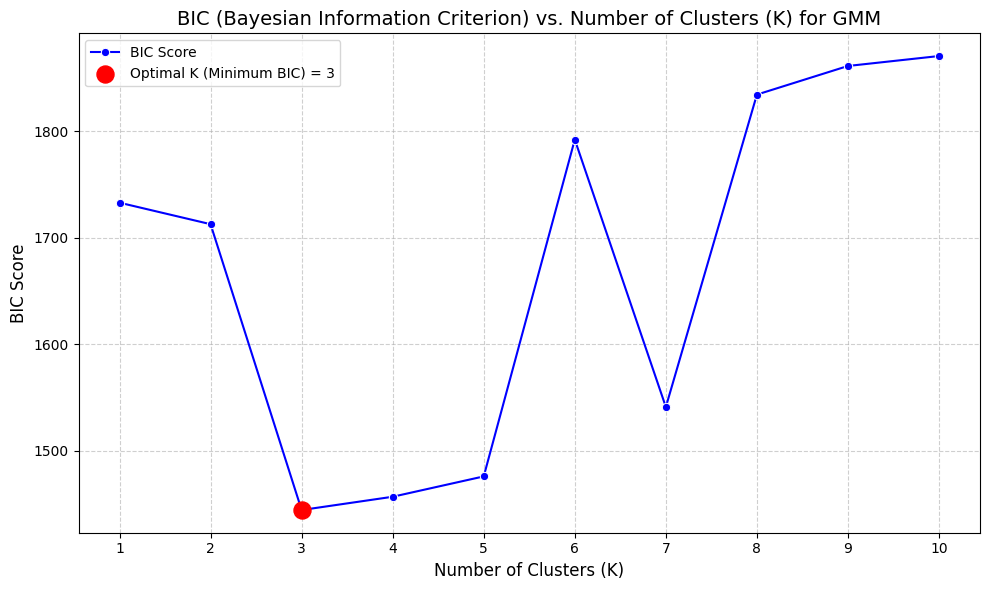

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot the BIC scores as a line plot
sns.lineplot(
    x='Number of Clusters (K)',
    y='BIC Score',
    data=results,
    marker='o',  # Add circles for each K value
    color='blue',
    label='BIC Score'
)

# Highlight the optimal K value found (K=3)
min_bic_k = results.loc[results['BIC Score'].idxmin(), 'Number of Clusters (K)']
min_bic_val = results['BIC Score'].min()

# Mark the best point with a red star
plt.scatter(
    min_bic_k,
    min_bic_val,
    color='red',
    s=150,
    marker='o',
    zorder=5, # Ensure the marker is visible above the line
    label=f'Optimal K (Minimum BIC) = {int(min_bic_k)}'
)

# Set the labels, title, and grid
plt.title('BIC (Bayesian Information Criterion) vs. Number of Clusters (K) for GMM', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('BIC Score', fontsize=12)

# Ensure the X-axis only shows integer values from 1 to 10
plt.xticks(results['Number of Clusters (K)'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture

# BIC
best_k = 3

# Final GMM model
gmm_final = GaussianMixture(n_components=best_k, random_state=42)
gmm_final.fit(X_scaled)

df['Cluster_Label'] = gmm_final.predict(X_scaled)

print(f"Final Model fitted with K={best_k}.")
print("\nCluster Distribution:")
print(df['Cluster_Label'].value_counts().sort_index())

Final Model fitted with K=3.

Cluster Distribution:
Cluster_Label
0     3
1    28
2    22
Name: count, dtype: int64


In [ ]:
# Cluster Profiling:
selected_features = features
cluster_profile = df.groupby('Cluster_Label')[selected_features].mean()

# Cluster size
cluster_size = df['Cluster_Label'].value_counts().sort_index().to_frame(name='Count')

# Final Analysis Table
final_analysis_df = pd.merge(cluster_size, cluster_profile,
                             left_index=True, right_index=True)

# Output
print("--- Cluster Analysis (Average Values) ---")
# round off the decimals
print(final_analysis_df.round(3))

--- Cluster Analysis (Average Values) ---
               Count    Age  Gender  Education  Occupation  Usage  avg_amount  \
Cluster_Label                                                                   
0                  3  1.000   0.000      1.000       1.333  0.000       0.667   
1                 28  1.679   0.321      0.964       1.286  1.821       0.357   
2                 22  1.455   0.909      0.909       0.955  1.773       1.045   

               overall_satisfaction  food_quality  delivery_time  packaging  \
Cluster_Label                                                                 
0                             5.000         4.667          5.000      4.667   
1                             3.321         2.714          2.714      3.036   
2                             3.955         3.909          3.955      4.136   

               value_for_money  
Cluster_Label                   
0                        5.000  
1                        2.750  
2                       

In [ ]:
# Cluster Profile Table
cluster_profiles = df.groupby('Cluster_Label')[
    ['Age', 'Education', 'Usage', 'avg_amount', 'packaging', 'overall_satisfaction']
].mean()

#  Cluster_Name column add
cluster_profiles['Cluster_Name'] = ""

#  --- Cluster Naming (Human Interpretation) ---
cluster_profiles.loc[0, 'Cluster_Name'] = 'Young, Value-Conscious Users (Budget Regulars)'
cluster_profiles.loc[1, 'Cluster_Name'] = 'Educated, Mid-Spenders (Balanced Quality & Price)'
cluster_profiles.loc[2, 'Cluster_Name'] = 'Older, Quality-Driven, Occasional Spenders'

# Final Table
print("--- Cluster Profiles with Names ---")
print(cluster_profiles[['Cluster_Name', 'Age', 'Usage', 'avg_amount', 'packaging']])

--- Cluster Profiles with Names ---
                                                    Cluster_Name       Age  \
Cluster_Label                                                                
0                 Young, Value-Conscious Users (Budget Regulars)  1.000000   
1              Educated, Mid-Spenders (Balanced Quality & Price)  1.678571   
2                     Older, Quality-Driven, Occasional Spenders  1.454545   

                  Usage  avg_amount  packaging  
Cluster_Label                                   
0              0.000000    0.666667   4.666667  
1              1.821429    0.357143   3.035714  
2              1.772727    1.045455   4.136364  


In [ ]:
# --- Function to get Top Words (Updated and Robust) ---
def get_top_words_by_cluster(df, cluster_id, top_n=5):

    # Filter text and combine
    feedback_text = ' '.join(
        df[df['Cluster_Label'] == cluster_id]['feedback'].astype(str).tolist()
    )
    # Remove non-alphanumeric characters and convert to lower
    feedback_text = re.sub(r'[^\w\s]', '', feedback_text.lower())

    # Updated Stop Words List
    stop_words = set([
        'my', 'food', 'it', 'was', 'time', 'price', 'zomato',
        'i', 'for', 'a', 'to', 'n', 'but', 'order', 'please',
        'the', 'is', 'and', 'good', 'delivery', 'with', 'thanks', 'just', 'nan', 'vary', 'like'
    ])

    words = [
        word for word in feedback_text.split()
        if word not in stop_words and len(word) > 2
    ]

    if not words:
        raw_feedback = df[df['Cluster_Label'] == cluster_id]['feedback'].head(1).iloc[0]
        return [(f"No meaningful words (Raw Sample: {raw_feedback})", 0)]

    word_counts = Counter(words)
    return word_counts.most_common(top_n)

print("\n--- NLP Interpretation (Top Words for ALL Clusters) ---")
sorted_clusters = sorted(df['Cluster_Label'].unique())
for i in sorted_clusters:
    top_words = get_top_words_by_cluster(df, i)
    print(f"Cluster {i} Top Words: {top_words}")


--- NLP Interpretation (Top Words for ALL Clusters) ---
Cluster 0 Top Words: [('excellent', 3), ('service', 1), ('are', 1), ('person', 1), ('also', 1)]
Cluster 1 Top Words: [('have', 4), ('ordered', 3), ('experience', 3), ('app', 3), ('person', 3)]
Cluster 2 Top Words: [('service', 7), ('are', 7), ('that', 4), ('services', 4), ('nice', 3)]


In [ ]:
%matplotlib inline

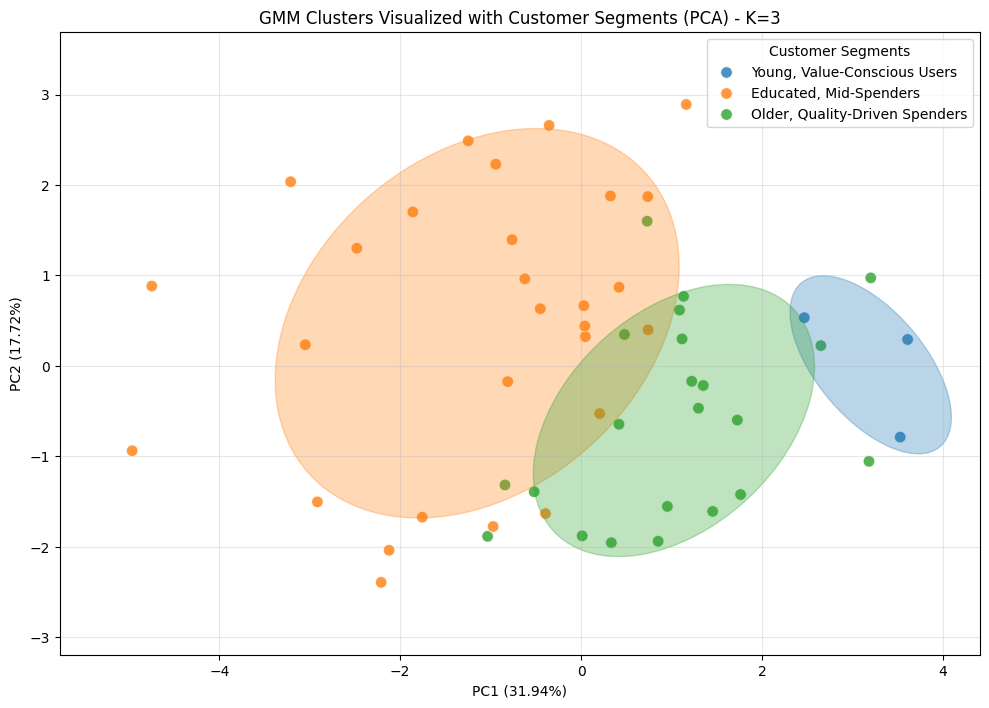

In [ ]:
# ================== IMPORTS ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA

# ================== PCA ==================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster_Label']

# ================== CLUSTER NAMES ==================
cluster_names = {
    0: 'Young, Value-Conscious Users',
    1: 'Educated, Mid-Spenders',
    2: 'Older, Quality-Driven Spenders'
}

# ================== ELLIPSE FUNCTION ==================
def draw_ellipse(position, covariance, ax, color, alpha=0.3, scale=2):
    U, s, _ = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * scale * np.sqrt(s)

    ell = Ellipse(
        xy=position,
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=alpha
    )
    ax.add_patch(ell)

# ================== PLOT ==================
fig, ax = plt.subplots(figsize=(10,8))
ax.set_aspect('equal')

unique_clusters = sorted(df_pca['Cluster'].unique())
palette = sns.color_palette('tab10', len(unique_clusters))
color_map = {c: palette[i] for i, c in enumerate(unique_clusters)}

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette=color_map,
    data=df_pca,
    s=70, alpha=0.8, ax=ax
)

# ================== CLUSTER-WISE PCA ELLIPSES ==================
for i in unique_clusters:
    pts = df_pca[df_pca['Cluster'] == i][['PC1','PC2']].values
    center = pts.mean(axis=0)
    cov = np.cov(pts.T)

    draw_ellipse(center, cov, ax, color_map[i], scale=1.4)

# ================== LEGEND ==================
legend = ax.get_legend()
legend.set_title("Customer Segments")
for t, l in zip(legend.texts, unique_clusters):
    t.set_text(cluster_names[l])

plt.title('GMM Clusters Visualized with Customer Segments (PCA) - K=3')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(alpha=0.3)
ax.set_xlim(df_pca['PC1'].min() - 0.8, df_pca['PC1'].max() + 0.8)
ax.set_ylim(df_pca['PC2'].min() - 0.8, df_pca['PC2'].max() + 0.8)
plt.tight_layout()
plt.margins(0.15)
plt.show()
